# 02 - Central Tendency, Dispersion, and Visualization


## 1) Learning Objectives

- Compute mean, median, and mode clearly.
- Compare variance, standard deviation, and range.
- Explain when median is better than mean.
- Use basic plots to support interpretation.


## 2) Why This Topic Matters

Two datasets can have the same mean but very different behavior.

To describe data responsibly, we need:

- center + spread,
- tables + plots,
- interpretation + context.


## 3) Short and Simple Theory Explanation

- **Mean**: arithmetic average, sensitive to outliers.
- **Median**: middle value, robust to outliers.
- **Mode**: most frequent value.
- **Variance**: average squared distance from mean.
- **Standard deviation**: square root of variance, in original units.
- **Range**: max - min.


## 4) Step-by-Step Code Examples

### Step 4.1 - Setup and load data

**What are we trying to learn?**  
Create a clean base for center/spread analysis.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

np.random.seed(42)
sns.set_theme(style="whitegrid")

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns=["target"])

numeric_cols = df.select_dtypes(include="number").columns.tolist()


**Interpretation**

Data are ready for central tendency and dispersion analysis.


### Step 4.2 - Mean, median, mode

**What should we expect?**  
Some features will have mean and median close to each other.


In [2]:
# Center measures side-by-side
center_table = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "mode_first": df[numeric_cols].mode().iloc[0]
})
center_table


,mean,median,mode_first
sepal length (cm),5.843333,5.80,5.0
sepal width (cm),3.057333,3.00,3.0
petal length (cm),3.758000,4.35,1.4
petal width (cm),1.199333,1.30,0.2


**Interpretation**

- Close mean and median often indicate lower skewness.
- Larger gap suggests asymmetry or outliers.

**Why this matters**

Choosing the wrong center can misrepresent what is typical.


### Step 4.3 - Mean vs median with an outlier (intuition)

**What are we doing?**  
Compare a clean list vs same list with one extreme value.


In [3]:
clean_scores = np.array([10, 11, 10, 12, 11, 10, 9, 11])
outlier_scores = np.append(clean_scores, 60)

compare_center = pd.DataFrame({
    "scenario": ["clean", "with_outlier"],
    "mean": [clean_scores.mean(), outlier_scores.mean()],
    "median": [np.median(clean_scores), np.median(outlier_scores)]
})
compare_center


,scenario,mean,median
0,clean,10.5,10.5
1,with_outlier,16.0,11.0


**Interpretation**

Mean changes sharply with one outlier, but median remains more stable.

**Common mistake**

Using mean by default for skewed or outlier-heavy data.


### Step 4.4 - Dispersion measures

**What should students notice?**  
Variance and standard deviation describe spread, but on different scales.


In [4]:
# Spread measures
spread_table = pd.DataFrame({
    "variance": df[numeric_cols].var(),
    "std_dev": df[numeric_cols].std(),
    "range": df[numeric_cols].max() - df[numeric_cols].min()
})
spread_table


,variance,std_dev,range
sepal length (cm),0.685694,0.828066,3.6
sepal width (cm),0.189979,0.435866,2.4
petal length (cm),3.116278,1.765298,5.9
petal width (cm),0.581006,0.762238,2.4


**Interpretation**

- Standard deviation is easier to communicate (same unit as data).
- Range can be distorted by only two extreme points.

**Why this matters**

Spread helps judge stability and uncertainty in measurements.


### Step 4.5 - Manual dispersion example (old notebook style)

**What are we doing?**  
Compute range, variance, and std manually on a tiny list.


In [5]:
small_data = [5, 7, 8, 7, 10, 6, 9, 8, 7, 6]

# Range
range_manual = max(small_data) - min(small_data)

# Mean needed for variance
mean_manual = sum(small_data) / len(small_data)

# Population variance (manual)
variance_manual = sum((x - mean_manual) ** 2 for x in small_data) / len(small_data)

# Population standard deviation (manual)
std_manual = variance_manual ** 0.5

print("Range:", range_manual)
print("Variance:", variance_manual)
print("Std Dev:", std_manual)


Range: 5
Variance: 2.0100000000000002
Std Dev: 1.4177446878757827


**Interpretation**

Manual formulas make package outputs easier to trust and explain.


### Step 4.6 - Visualize center and spread patterns

**What should we look for?**

- Histogram: shape and tails,
- Boxplot: median, spread, possible outliers,
- Scatter: variable relationship and cluster hints.


/var/folders/w0/2jgnn0bx27b_jyy4mrm45cxm0000gn/T/ipykernel_6306/2398730400.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y="petal width (cm)", ax=axes[1], palette="Set2")


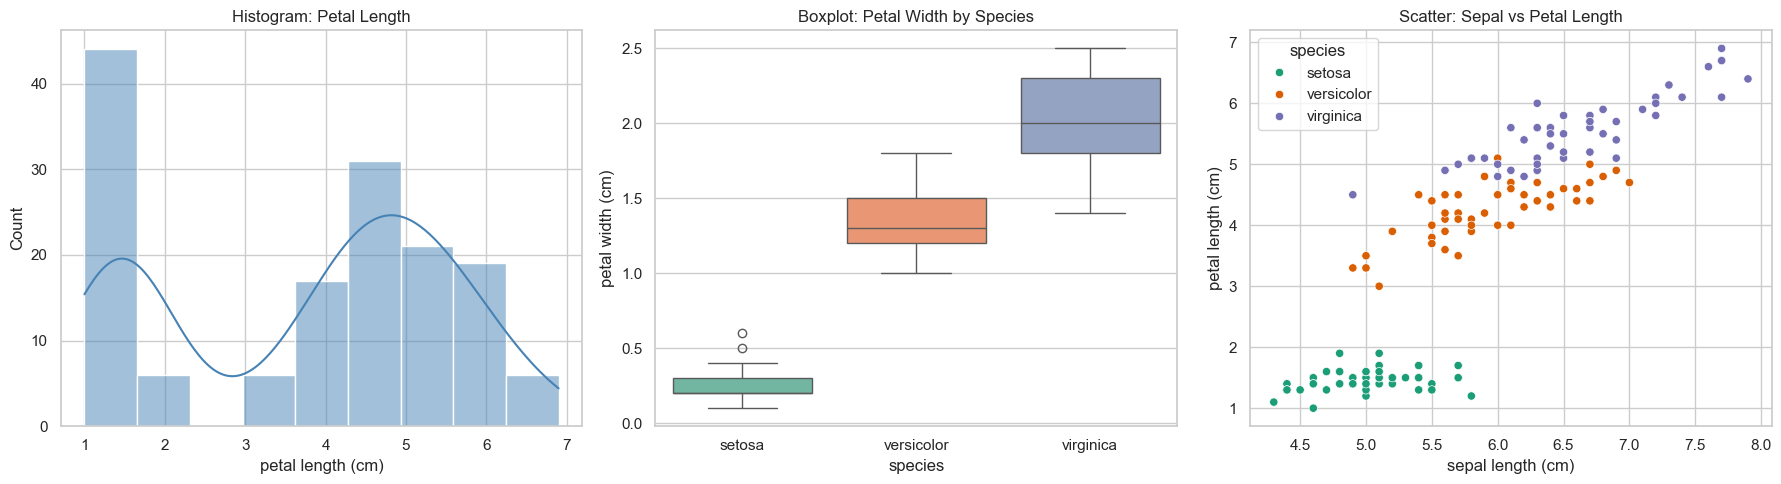

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution shape
sns.histplot(df["petal length (cm)"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram: Petal Length")

# Group center/spread comparison
sns.boxplot(data=df, x="species", y="petal width (cm)", ax=axes[1], palette="Set2")
axes[1].set_title("Boxplot: Petal Width by Species")

# Relationship between two features
sns.scatterplot(data=df, x="sepal length (cm)", y="petal length (cm)", hue="species", ax=axes[2], palette="Dark2")
axes[2].set_title("Scatter: Sepal vs Petal Length")

plt.tight_layout()
plt.show()


**Interpretation**

Plots confirm that species differ in central level and spread, especially for petal measures.

**Why this matters**

Visualization helps validate table-based conclusions before formal tests.


## 8) Small Concept Check Questions (with answers)

**Q1:** Why report standard deviation instead of only variance?  
**A1:** Standard deviation is in the same unit as the data, so it is easier to interpret.

**Q2:** When is median preferred over mean?  
**A2:** When data are skewed or contain strong outliers.


## 9) Key Takeaways

- Center and spread must be interpreted together.
- Mean is sensitive, median is robust.
- Dispersion measures answer different practical questions.
- Plots improve understanding and reduce misinterpretation.


## 10) Optional Short Practice / Challenge

- Create a boxplot for each numeric feature by species.
- Write one sentence interpreting each plot.
